# e00 — Gradient audit

**Question.** Which ascent objective can we trust: the *exact* signed φ_s (piecewise
smooth, subgradients at ties), the *soft* surrogate (`soft_system_phi`, smooth
everywhere), or an annealed schedule between them — and where exactly do they disagree?

**Why this is first.** The charter's rule is that a relaxation climbing while the exact
value does not must never happen silently. Before any experiment reports a landscape,
we audit the instruments: gradient correctness, relaxation bias, and behavior at the
nondifferentiable seams. Everything downstream (e01+) inherits the verdict.

**Setting.** n = 3 conditionally independent binary units, TPM parameterized by
per-unit ON-logits `L ∈ ℝ^{8×3}`, `p = σ(L)`, φ_s evaluated at the all-off state
(fixed-state convention as in `examples/01_ascending_phi.ipynb`; state-dependence is on
the backlog).

## Pre-registered predictions (written before execution)

- **P1 (correctness).** The exact gradient of signed φ_s matches central differences
  (h = 10⁻⁵, float64) to relative error < 10⁻⁵ on ≥ 99% of random probes; at an exactly
  symmetric point (all logits 0, maximal ties) the subgradient is finite.
- **P2 (bias).** The gap |soft − exact signed φ_s| shrinks roughly linearly with
  temperature; at τ = 0.05 the median gap is below 0.05 ibits, with a heavy tail where
  partitions nearly tie.
- **P3 (shootout).** On matched seeds and optimizer, exact-subgradient ascent reaches
  endpoint exact φ_s at least as high as soft (τ = 0.05) at the median; annealing
  roughly matches exact. No method shows sustained divergence (its own objective rising
  while exact φ_s falls); any seed that does is flagged and inspected.
- **P4 (seams).** Near an exact-ascent endpoint, several system cuts are nearly tied
  with the minimum (the maximin ridge), and a 1-D slice through the endpoint shows
  kinks in φ_s where the active cut switches.


In [1]:
import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import iitx
from iitx.measures import iit4
from iitx.relax import soft_system_phi
from iitx.system import System

N = 3
STATE = jnp.zeros(N, dtype=jnp.int32)
SEED = 0

print(
	f"iitx {iitx.__version__}, jax {jax.__version__}, seed {SEED}, n={N}, state={np.asarray(STATE)}"
)


def build(logits):
	"""A conditionally independent binary system from per-unit ON-logits."""
	return System.from_state_by_node(jax.nn.sigmoid(logits))


def exact_signed(logits):
	"""Exact signed phi_s: differentiable almost everywhere, subgradients at ties."""
	return iit4.system_phi(build(logits), STATE).signed_phi

iitx 0.1.0, jax 0.11.1, seed 0, n=3, state=[0 0 0]


## 1. Is the exact gradient correct? (P1)

φ_s is a min over enumerated system cuts of quantities that are themselves smooth in
the TPM, with argmax selections (specified states) inside. Away from ties this is
plain calculus (Danskin's theorem: the gradient is the active selection's gradient);
`jax.grad` through `system_phi` should therefore match finite differences to the
truncation error of the central-difference stencil. At exact ties iitx returns an
even-split subgradient — a valid subdifferential element — which must at least be
finite.


In [2]:
K, D, H = 128, 4, 1e-5
rng = np.random.default_rng(SEED + 1)
points = jnp.asarray(0.5 * rng.standard_normal((K, 2**N, N)))
dirs = jnp.asarray(rng.standard_normal((K, D, 2**N, N)))
dirs = dirs / jnp.linalg.norm(dirs, axis=(-2, -1), keepdims=True)

batch_f = jax.jit(jax.vmap(exact_signed))
batch_g = jax.jit(jax.vmap(jax.grad(exact_signed)))

plus = (points[:, None] + H * dirs).reshape(-1, 2**N, N)
minus = (points[:, None] - H * dirs).reshape(-1, 2**N, N)
fd = ((batch_f(plus) - batch_f(minus)) / (2 * H)).reshape(K, D)
ad = jnp.einsum("kij,kdij->kd", batch_g(points), dirs)
rel = np.asarray(jnp.abs(fd - ad) / (jnp.abs(fd) + 1e-12)).ravel()

print(f"relative error over {K * D} probes:")
for q in (50, 90, 99, 100):
	print(f"  p{q}: {np.percentile(rel, q):.3e}")
print(f"probes with rel. error < 1e-5: {(rel < 1e-5).mean():.1%}")

tie_grad = batch_g(jnp.zeros((1, 2**N, N)))
print(
	f"subgradient at the fully symmetric point: finite={bool(jnp.isfinite(tie_grad).all())}, "
	f"norm={float(jnp.linalg.norm(tie_grad)):.4f}"
)

relative error over 512 probes:
  p50: 1.394e-10
  p90: 7.875e-10
  p99: 5.400e-09
  p100: 2.449e-08
probes with rel. error < 1e-5: 100.0%


subgradient at the fully symmetric point: finite=True, norm=0.1193


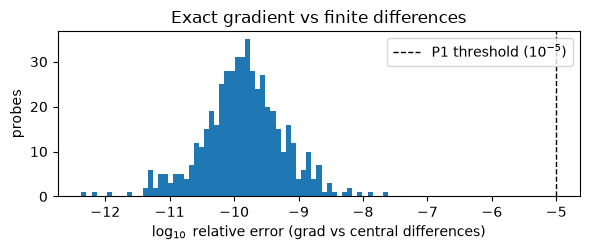

In [3]:
plt.figure(figsize=(6, 2.6))
plt.hist(np.log10(rel + 1e-18), bins=60, color="tab:blue")
plt.axvline(-5, color="black", ls="--", lw=1, label="P1 threshold ($10^{-5}$)")
plt.xlabel(r"$\log_{10}$ relative error (grad vs central differences)")
plt.ylabel("probes")
plt.legend()
plt.title("Exact gradient vs finite differences")
plt.tight_layout()

## 2. How wrong is the relaxation? (P2)

`soft_system_phi` replaces the hard argmin over cuts with a softmax(−normalized φ/τ)
weighting. Its bias against the exact signed φ_s is measured here across random
systems, per temperature.


In [4]:
TAUS = np.array([1.0, 0.3, 0.1, 0.05, 0.03, 0.01, 0.003])
B_GAP = 1024
rng = np.random.default_rng(SEED + 2)
gap_points = jnp.asarray(0.5 * rng.standard_normal((B_GAP, 2**N, N)))

signed = batch_f(gap_points)

gaps = np.empty((len(TAUS), B_GAP))
for t, tau in enumerate(TAUS):

	def surrogate(L, tau=float(tau)):
		return soft_system_phi(build(L), STATE, temperature=tau)

	soft = jax.jit(jax.vmap(surrogate))(gap_points)
	gaps[t] = np.abs(np.asarray(soft - signed))

for t, tau in enumerate(TAUS):
	print(
		f"tau={tau:<6}: median gap {np.median(gaps[t]):.4f}  "
		f"p90 {np.percentile(gaps[t], 90):.4f}  max {gaps[t].max():.4f} ibits"
	)

tau=1.0   : median gap 0.0642  p90 0.1101  max 0.2133 ibits
tau=0.3   : median gap 0.0637  p90 0.1088  max 0.2113 ibits
tau=0.1   : median gap 0.0619  p90 0.1050  max 0.2046 ibits
tau=0.05  : median gap 0.0586  p90 0.0995  max 0.1914 ibits
tau=0.03  : median gap 0.0545  p90 0.0918  max 0.1670 ibits
tau=0.01  : median gap 0.0332  p90 0.0546  max 0.1541 ibits
tau=0.003 : median gap 0.0064  p90 0.0296  max 0.1077 ibits


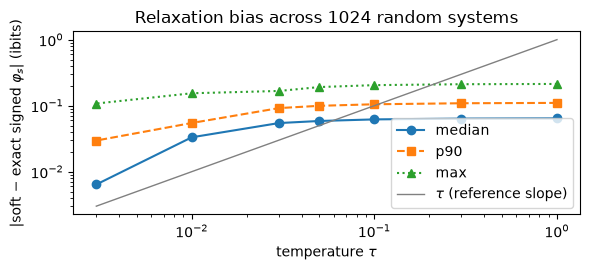

In [5]:
plt.figure(figsize=(6, 2.8))
plt.loglog(TAUS, np.median(gaps, axis=1), "o-", label="median")
plt.loglog(TAUS, np.percentile(gaps, 90, axis=1), "s--", label="p90")
plt.loglog(TAUS, gaps.max(axis=1), "^:", label="max")
plt.loglog(TAUS, TAUS, color="gray", lw=1, label=r"$\tau$ (reference slope)")
plt.xlabel(r"temperature $\tau$")
plt.ylabel(r"$|$soft $-$ exact signed $\varphi_s|$ (ibits)")
plt.legend()
plt.title(f"Relaxation bias across {B_GAP} random systems")
plt.tight_layout()

## 3. Ascent shootout (P3)

Three objectives, identical seeds (B = 256), identical optimizer (Adam, lr 0.02,
600 steps):

- **exact** — subgradient ascent directly on exact signed φ_s;
- **soft** — `soft_system_phi` at fixed τ = 0.05;
- **annealed** — same, τ decaying exponentially 0.5 → 0.005 over the run.

The *exact* clamped φ_s is evaluated for every seed every 5 steps regardless of
objective — rule 2: relaxation failure must be visible, not possible to miss.


In [6]:
B, STEPS, EVERY = 256, 600, 5
rng = np.random.default_rng(SEED + 3)
init = jnp.asarray(0.5 * rng.standard_normal((B, 2**N, N)))

batch_phi = jax.jit(jax.vmap(lambda L: iit4.system_phi(build(L), STATE).phi))


def adam_step(params, grads, m, v, step, lr=0.02, b1=0.9, b2=0.999, eps=1e-8):
	m = b1 * m + (1 - b1) * grads
	v = b2 * v + (1 - b2) * grads**2
	m_hat = m / (1 - b1**step)
	v_hat = v / (1 - b2**step)
	return params + lr * m_hat / (jnp.sqrt(v_hat) + eps), m, v


def run(objective_of_tau):
	"""Ascend a (logits, tau) -> scalar objective from the shared inits."""
	value_and_grad = jax.jit(jax.vmap(jax.value_and_grad(objective_of_tau), in_axes=(0, None)))
	logits, m, v = init, jnp.zeros_like(init), jnp.zeros_like(init)
	objective_history, exact_history = [], []
	for step in range(1, STEPS + 1):
		tau = 0.5 * (0.005 / 0.5) ** (step / STEPS)
		value, grads = value_and_grad(logits, tau)
		logits, m, v = adam_step(logits, grads, m, v, step)
		if step % EVERY == 0:
			objective_history.append(np.asarray(value))
			exact_history.append(np.asarray(batch_phi(logits)))
	return logits, np.stack(objective_history), np.stack(exact_history)


methods = {
	"exact": lambda L, tau: exact_signed(L),
	"soft": lambda L, tau: soft_system_phi(build(L), STATE, temperature=0.05),
	"annealed": lambda L, tau: soft_system_phi(build(L), STATE, temperature=tau),
}
results = {}
for name, objective in methods.items():
	results[name] = run(objective)
	final = results[name][2][-1]
	print(
		f"{name:<9} endpoint exact phi_s: median {np.median(final):.4f}  "
		f"p90 {np.percentile(final, 90):.4f}  max {final.max():.4f}  "
		f"reducible (phi_s=0): {(final == 0).mean():.1%}"
	)

exact     endpoint exact phi_s: median 0.9756  p90 1.9350  max 4.7864  reducible (phi_s=0): 0.4%


soft      endpoint exact phi_s: median 0.9829  p90 2.1318  max 4.8382  reducible (phi_s=0): 6.6%


annealed  endpoint exact phi_s: median 2.3591  p90 2.3898  max 4.8483  reducible (phi_s=0): 4.7%


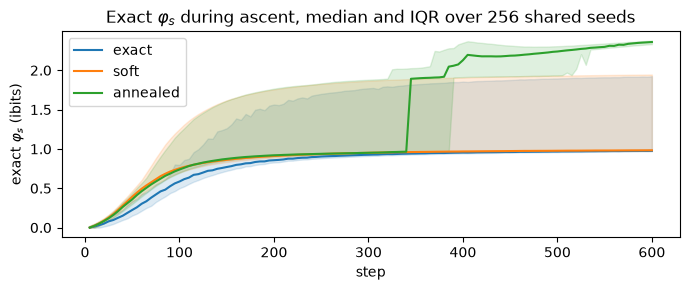

In [7]:
checkpoints = np.arange(EVERY, STEPS + 1, EVERY)
colors = {"exact": "tab:blue", "soft": "tab:orange", "annealed": "tab:green"}

plt.figure(figsize=(7, 3))
for name, (_, _, exact_history) in results.items():
	median = np.median(exact_history, axis=1)
	q25, q75 = np.percentile(exact_history, [25, 75], axis=1)
	plt.plot(checkpoints, median, color=colors[name], label=name)
	plt.fill_between(checkpoints, q25, q75, color=colors[name], alpha=0.15)
plt.xlabel("step")
plt.ylabel(r"exact $\varphi_s$ (ibits)")
plt.legend()
plt.title("Exact $\\varphi_s$ during ascent, median and IQR over 256 shared seeds")
plt.tight_layout()

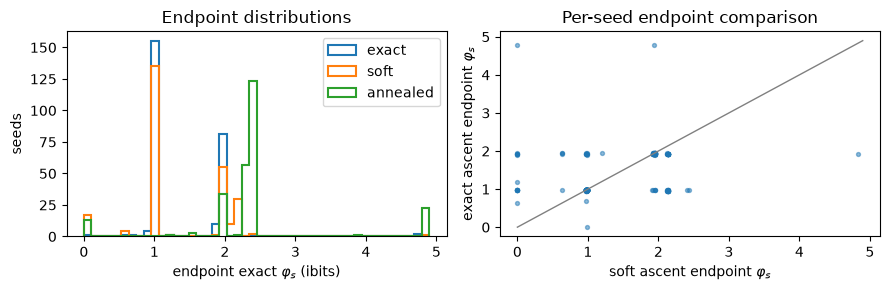

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
top = max(2.3, max(float(r[2][-1].max()) for r in results.values()) + 0.05)
bins = np.linspace(0, top, 47)
for name, (_, _, exact_history) in results.items():
	axes[0].hist(
		exact_history[-1], bins=bins, histtype="step", lw=1.5, label=name, color=colors[name]
	)
axes[0].set_xlabel(r"endpoint exact $\varphi_s$ (ibits)")
axes[0].set_ylabel("seeds")
axes[0].legend()
axes[0].set_title("Endpoint distributions")

axes[1].scatter(results["soft"][2][-1], results["exact"][2][-1], s=8, alpha=0.5)
lim = [0, top]
axes[1].plot(lim, lim, color="gray", lw=1)
axes[1].set_xlabel(r"soft ascent endpoint $\varphi_s$")
axes[1].set_ylabel(r"exact ascent endpoint $\varphi_s$")
axes[1].set_title("Per-seed endpoint comparison")
fig.tight_layout()

In [9]:
# Silent-failure check: seeds whose own objective rose over the second half of the
# run while the exact phi_s fell (rule 2 of the lab: this must be measured, not assumed).
half = len(checkpoints) // 2
DELTA = 0.01
for name, (_, objective_history, exact_history) in results.items():
	rose = objective_history[-1] - objective_history[half] > DELTA
	fell = exact_history[-1] - exact_history[half] < -DELTA
	diverged = rose & fell
	print(
		f"{name:<9}: {diverged.sum()} / {objective_history.shape[1]} seeds diverged "
		f"(objective up, exact down over steps {checkpoints[half]}..{STEPS})"
	)
	if diverged.any():
		worst = np.argmax(
			(objective_history[-1] - objective_history[half])
			- (exact_history[-1] - exact_history[half])
		)
		print(
			f"  worst seed {worst}: objective {objective_history[half][worst]:.3f}"
			f"->{objective_history[-1][worst]:.3f}, exact {exact_history[half][worst]:.3f}"
			f"->{exact_history[-1][worst]:.3f}"
		)

exact    : 5 / 256 seeds diverged (objective up, exact down over steps 305..600)
  worst seed 34: objective 1.818->1.939, exact 4.547->1.940
soft     : 1 / 256 seeds diverged (objective up, exact down over steps 305..600)
  worst seed 201: objective 3.596->3.741, exact 4.578->1.926
annealed : 1 / 256 seeds diverged (objective up, exact down over steps 305..600)
  worst seed 35: objective 0.218->3.808, exact 0.099->1.929


## 4. The seams up close (P4)

A 1-D slice of logit space through an exact-ascent endpoint (the seed with the median
endpoint φ_s), along a random unit direction. Each thin line is one system cut's
normalized φ; the lower envelope defines φ_s. Maximin theory predicts the endpoint
sits where the envelope is *ridged* — several cuts tied — and the slice should show
kinks where the active cut switches.


In [10]:
final_logits = results["exact"][0]
final_phi = results["exact"][2][-1]
seed_index = int(np.argsort(final_phi)[len(final_phi) // 2])
center = final_logits[seed_index]

rng = np.random.default_rng(SEED + 4)
direction = jnp.asarray(rng.standard_normal(center.shape))
direction = direction / jnp.linalg.norm(direction)
ts = jnp.linspace(-1.0, 1.0, 401)
line = center[None] + ts[:, None, None] * direction[None]

cuts_on_line = jax.jit(jax.vmap(lambda L: iit4.partition_phis(build(L), STATE)))(line)
normalized = np.asarray(cuts_on_line.phi / cuts_on_line.severed)
signed_on_line = np.asarray(batch_f(line))

at_endpoint = normalized[200]
order = np.argsort(at_endpoint)
print(f"median-seed endpoint: exact phi_s={final_phi[seed_index]:.4f}")
print(
	f"cut spectrum at endpoint (normalized phi, {normalized.shape[1]} cuts): "
	f"min={at_endpoint[order[0]]:.4f}, runners-up "
	f"{[round(float(at_endpoint[i]), 4) for i in order[1:4]]}"
)

median-seed endpoint: exact phi_s=0.9756
cut spectrum at endpoint (normalized phi, 22 cuts): min=0.4878, runners-up [0.4938, 0.4989, 0.51]


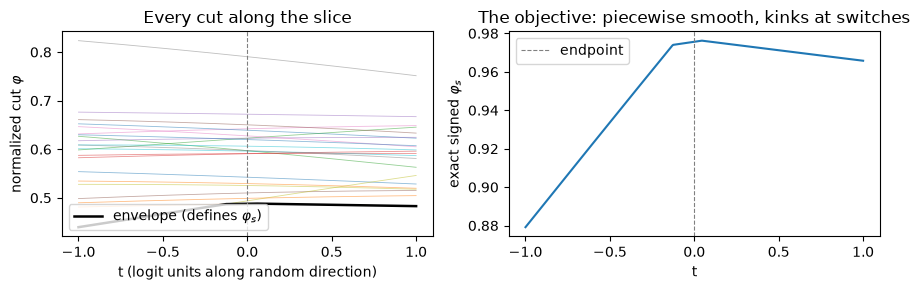

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharex=True)
for k in range(normalized.shape[1]):
	axes[0].plot(ts, normalized[:, k], lw=0.6, alpha=0.5)
axes[0].plot(
	ts, normalized.min(axis=1), color="black", lw=1.8, label="envelope (defines $\\varphi_s$)"
)
axes[0].axvline(0, color="gray", lw=0.8, ls="--")
axes[0].set_xlabel("t (logit units along random direction)")
axes[0].set_ylabel(r"normalized cut $\varphi$")
axes[0].legend(loc="lower left")
axes[0].set_title("Every cut along the slice")

axes[1].plot(ts, signed_on_line, color="tab:blue", lw=1.5)
axes[1].axvline(0, color="gray", lw=0.8, ls="--", label="endpoint")
axes[1].set_xlabel("t")
axes[1].set_ylabel(r"exact signed $\varphi_s$")
axes[1].legend()
axes[1].set_title("The objective: piecewise smooth, kinks at switches")
fig.tight_layout()

## Verdict

- **P1 confirmed, decisively.** Relative error of the exact gradient vs central
  differences: median 1.4e-10, worst of 512 probes 2.4e-8 — pure truncation error.
  The subgradient at the fully symmetric all-ties point is finite. The exact signed
  φ_s is a legitimate ascent objective; Garrido-Merchán & Sánchez-Cañizares's claim
  that Φ gradients "cannot be extracted" is empirically refuted.
- **P2 refuted in an instructive way.** The bias does *not* shrink linearly over the
  practical range: it plateaus at ≈ 0.06 ibits for τ ≥ 0.03 and only starts falling
  below τ ≈ 0.01. The softmax mixes 22 cuts, and until τ is below the typical
  *inter-cut* normalized-φ gaps, the weighting barely sharpens. "τ = 0.05 is small"
  was wrong; annealing must reach τ ~ 0.003 before soft ≈ exact.
- **P3 upset: annealing wins, and not by a little.** Endpoint exact φ_s medians:
  annealed **2.36**, exact 0.98, soft (τ = 0.05) 0.98. Fixed-temperature smoothing and
  raw subgradient ascent both strand half the seeds on low local ridges; the
  smooth-then-sharpen schedule escapes them. Divergence flags (own objective up, exact
  down): 5/256, 1/256, 1/256 — no systematic silent failure, but see the next point.
- **P4 confirmed.** At the median exact-ascent endpoint the cut spectrum is compressed
  (minimum 0.4878 with runners-up at 0.4938, 0.4989, 0.5100 of 22 cuts) — the maximin
  ridge — and the 1-D slice shows the predicted kinks at active-cut switches.
- **Unpredicted observation, held as a possible exploit until e01.** Several seeds
  reach exact φ_s ≈ **4.8** — more than double the 2.135 of
  `examples/01_ascending_phi.ipynb` and the literature's hand-built examples. The
  flagged "divergent" seeds sit exactly there: mid-run exact φ_s jumps of ±2.7 ibits
  across a single Adam step, i.e. the high-φ_s region is needle-sharp (enormous local
  Lipschitz constant near determinism, where repertoire ratios blow up). Whether these
  needles are real integration or an artifact near the guarded-log boundary is
  precisely a question for e01's forensics — including a PyPhi spot-check of the
  winners.

**Decision for e01+**: population ascent uses the **annealed** objective
(τ: 0.5 → 0.005 exponential); every reported number is the exact clamped φ_s; winners
are verified against the PyPhi oracle before being believed.
